<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding How The Data Is Distributed**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform Exploratory Data Analysis (EDA). You will examine the structure of the data, visualize key variables, and analyze trends related to developer experience, tools, job satisfaction, and other important aspects.


## Objectives


In this lab you will perform the following:


- Understand the structure of the dataset.

- Perform summary statistics and data visualization.

- Identify trends in developer experience, tools, job satisfaction, and other key variables.


### Install the required libraries


In [91]:
!pip install pandas
!pip install matplotlib
!pip install seaborn


In [92]:
!pip install matplotlib-venn

In [93]:
!pip install country_converter --upgrade

### Step 1: Import Libraries and Load Data


- Import the `pandas`, `matplotlib.pyplot`, and `seaborn` libraries.


- You will begin with loading the dataset. You can use the pyfetch method if working on JupyterLite. Otherwise, you can use pandas' read_csv() function directly on their local machines or cloud environments.


In [94]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Stack Overflow survey dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

# Display the first few rows of the dataset
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Step 2: Examine the Structure of the Data


- Display the column names, data types, and summary information to understand the data structure.

- Objective: Gain insights into the dataset's shape and available variables.


In [95]:
## Write your code here
df.columns

Index(['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check',
       'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline',
       ...
       'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9',
       'JobSatPoints_10', 'JobSatPoints_11', 'SurveyLength', 'SurveyEase',
       'ConvertedCompYearly', 'JobSat'],
      dtype='object', length=114)

In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), object(100)
memory usage: 56.9+ MB


In [97]:
df.describe()

,ResponseId,CompTotal,WorkExp,JobSatPoints_1,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,ConvertedCompYearly,JobSat
count,65437.000000,3.374000e+04,29658.000000,29324.000000,29393.000000,29411.000000,29450.000000,29448.00000,29456.000000,29456.000000,29450.000000,29445.000000,2.343500e+04,29126.000000
mean,32719.000000,2.963841e+145,11.466957,18.581094,7.522140,10.060857,24.343232,22.96522,20.278165,16.169432,10.955713,9.953948,8.615529e+04,6.935041
std,18890.179119,5.444117e+147,9.168709,25.966221,18.422661,21.833836,27.089360,27.01774,26.108110,24.845032,22.906263,21.775652,1.867570e+05,2.088259
min,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000e+00,0.000000
25%,16360.000000,6.000000e+04,4.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,3.271200e+04,6.000000
50%,32719.000000,1.100000e+05,9.000000,10.000000,0.000000,0.000000,20.000000,15.00000,10.000000,5.000000,0.000000,0.000000,6.500000e+04,7.000000
75%,49078.000000,2.500000e+05,16.000000,22.000000,5.000000,10.000000,30.000000,30.00000,25.000000,20.000000,10.000000,10.000000,1.079715e+05,8.000000
max,65437.000000,1.000000e+150,50.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,1.625660e+07,10.000000


In [98]:
df.shape

(65437, 114)

In [99]:
df.dtypes

ResponseId               int64
MainBranch              object
Age                     object
Employment              object
RemoteWork              object
                        ...   
JobSatPoints_11        float64
SurveyLength            object
SurveyEase              object
ConvertedCompYearly    float64
JobSat                 float64
Length: 114, dtype: object

In [100]:
df.duplicated().sum()

np.int64(0)

### Step 3: Handle Missing Data


- Identify missing values in the dataset.

- Impute or remove missing values as necessary to ensure data completeness.



In [101]:
missing_data = df.isnull()

for column in missing_data.columns.values.tolist():
    print(column)
    print (missing_data[column].value_counts())
    print("")

ResponseId
ResponseId
False    65437
Name: count, dtype: int64

MainBranch
MainBranch
False    65437
Name: count, dtype: int64

Age
Age
False    65437
Name: count, dtype: int64

Employment
Employment
False    65437
Name: count, dtype: int64

RemoteWork
RemoteWork
False    54806
True     10631
Name: count, dtype: int64

Check
Check
False    65437
Name: count, dtype: int64

CodingActivities
CodingActivities
False    54466
True     10971
Name: count, dtype: int64

EdLevel
EdLevel
False    60784
True      4653
Name: count, dtype: int64

LearnCode
LearnCode
False    60488
True      4949
Name: count, dtype: int64

LearnCodeOnline
LearnCodeOnline
False    49237
True     16200
Name: count, dtype: int64

TechDoc
TechDoc
False    40897
True     24540
Name: count, dtype: int64

YearsCode
YearsCode
False    59869
True      5568
Name: count, dtype: int64

YearsCodePro
YearsCodePro
False    51610
True     13827
Name: count, dtype: int64

DevType
DevType
False    59445
True      5992
Name: count, dty

In [102]:
df.isnull().sum()

ResponseId                 0
MainBranch                 0
Age                        0
Employment                 0
RemoteWork             10631
                       ...  
JobSatPoints_11        35992
SurveyLength            9255
SurveyEase              9199
ConvertedCompYearly    42002
JobSat                 36311
Length: 114, dtype: int64

In [103]:
df['RemoteWork'].isnull().sum()

np.int64(10631)

In [104]:
df['RemoteWork'] = df['RemoteWork'].replace('Hybrid (some remote, some in-person)', 'Hybrid')

In [105]:
mode_rmwk = df['RemoteWork'].mode()[0]
print(mode_rmwk)

Hybrid


In [106]:
df['RemoteWork'] = df['RemoteWork'].fillna(mode_rmwk)

In [107]:
df['RemoteWork'].isnull().sum()

np.int64(0)

In [108]:
df['ConvertedCompYearly'].isnull().sum()

np.int64(42002)

In [109]:
mean_concompyr = df['ConvertedCompYearly'].mean()
print(mean_concompyr)

86155.28726264134


In [110]:
df['ConvertedCompYearly'] = df['ConvertedCompYearly'].fillna(mean_concompyr)

In [111]:
df['ConvertedCompYearly'].isnull().sum()

np.int64(0)

In [112]:
df['JobSat'].isnull().sum()

np.int64(36311)

In [113]:
mean_jbst = int(df['JobSat'].mean()) # Finding mean 'JobSat'
print(mean_jbst)

6


In [114]:
df['JobSat'] = df['JobSat'].fillna(mean_jbst)

In [115]:
df['JobSat'].isnull().sum()

np.int64(0)

In [116]:
df['YearsCodePro'].isnull().sum()

np.int64(13827)

In [117]:
mode_yrcdpro = df['YearsCodePro'].mode()[0]
print(mode_yrcdpro)

2


In [118]:
df['YearsCodePro'] = df['YearsCodePro'].fillna(mode_yrcdpro)

In [119]:
df['YearsCodePro'].isnull().sum()

np.int64(0)

In [120]:
df_Time = df.dropna(subset=['TimeSearching', 'TimeAnswering'])

### Step 4: Analyze Key Columns


- Examine key columns such as `Employment`, `JobSat` (Job Satisfaction), and `YearsCodePro` (Professional Coding Experience).

- **Instruction**: Calculate the value counts for each column to understand the distribution of responses.



In [121]:
## Write your code here
df[['Employment', 'JobSat', 'YearsCodePro']].head()

,Employment,JobSat,YearsCodePro
0,"Employed, full-time",6.0,2
1,"Employed, full-time",6.0,17
2,"Employed, full-time",6.0,27
3,"Student, full-time",6.0,2
4,"Student, full-time",6.0,2


In [122]:
df[['Employment', 'JobSat', 'YearsCodePro']].dtypes

Employment       object
JobSat          float64
YearsCodePro     object
dtype: object

In [123]:
df[['JobSat']].describe()

,JobSat
count,65437.000000
mean,6.416187
std,1.468642
min,0.000000
25%,6.000000
50%,6.000000
75%,7.000000
max,10.000000


In [124]:
df['Employment'].value_counts()

Employment
Employed, full-time                                                                                                                                   39041
Independent contractor, freelancer, or self-employed                                                                                                   4846
Student, full-time                                                                                                                                     4709
Employed, full-time;Independent contractor, freelancer, or self-employed                                                                               3557
Not employed, but looking for work                                                                                                                     2341
                                                                                                                                                      ...  
Not employed, but looking for work;Independent contra

In [125]:
jobsat_counts = df['JobSat'].value_counts()
print(jobsat_counts)

JobSat
6.0     40062
8.0      7509
7.0      6379
9.0      3626
10.0     2251
5.0      1956
3.0      1165
4.0      1130
2.0       772
0.0       311
1.0       276
Name: count, dtype: int64


In [126]:
df['YearsCodePro'].value_counts()

YearsCodePro
2                     17995
3                      4093
5                      3526
10                     3251
4                      3215
Less than 1 year       2856
6                      2843
1                      2639
8                      2549
7                      2517
12                     1777
15                     1635
20                     1549
9                      1493
11                     1312
13                     1127
14                     1082
25                      998
16                      946
18                      867
17                      814
30                      689
24                      632
19                      516
22                      492
23                      448
26                      426
27                      380
21                      380
28                      342
35                      285
29                      196
40                      194
32                      194
34                      169
38     

### Step 5: Visualize Job Satisfaction (Focus on JobSat)


- Create a pie chart or KDE plot to visualize the distribution of `JobSat`.

- Provide an interpretation of the plot, highlighting key trends in job satisfaction.


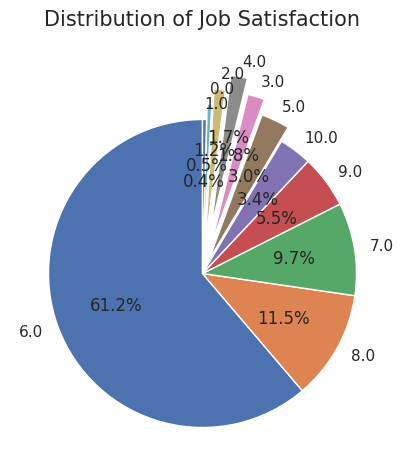

In [127]:
## Write your code here
# Create pie chart
explode = (0,0,0,0,0, 0.1, 0.2, 0.3, 0.2, 0.1, 0)
plt.figure(figsize=(5,5))
plt.pie(jobsat_counts, labels=jobsat_counts.index, explode=explode, autopct='%1.1f%%', startangle= 90)
plt.title('Distribution of Job Satisfaction', pad=40, fontsize=15)
plt.show()

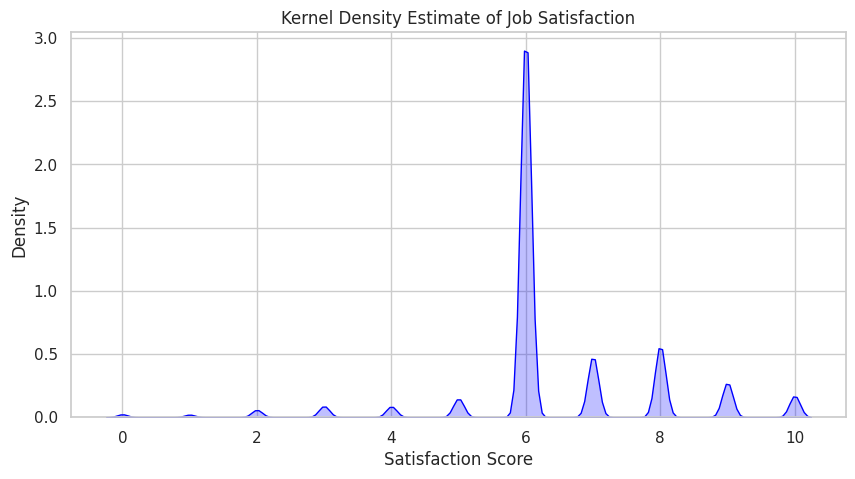

In [128]:
# Create KDE plot
plt.figure(figsize=(10, 5))
sns.kdeplot(df['JobSat'], fill=True, color="blue", bw_adjust=0.5)
plt.title('Kernel Density Estimate of Job Satisfaction')
plt.xlabel('Satisfaction Score')
plt.ylabel('Density')
plt.show()

Interpretation
Job Satisfaction ranges from 0 to 10 in categories, where 0 is the least and 10 is the highest score for job satisfaction. According to the pie chart, it is clearly seen that more than half of the respondents approximately 61.2% have the job satisfaction rate of 6. The dissatisfaction rate is only under 6%. KDE chart show the density of each score. The chart shows that starting from satisfaction score of 6, the spikes beccome higher. It can be deduced that the satisfaction rate is higher than dissatisfaction rate.

### Step 6: Programming Languages Analysis


- Compare the frequency of programming languages in `LanguageHaveWorkedWith` and `LanguageWantToWorkWith`.
  
- Visualize the overlap or differences using a Venn diagram or a grouped bar chart.


In [129]:
## Write your code here
df[['LanguageHaveWorkedWith', 'LanguageWantToWorkWith']].head()

,LanguageHaveWorkedWith,LanguageWantToWorkWith
0,NaN,NaN
1,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...
2,C#,C#
3,C;C++;HTML/CSS;Java;JavaScript;PHP;PowerShell;...,HTML/CSS;Java;JavaScript;PowerShell;Python;SQL...
4,C++;HTML/CSS;JavaScript;Lua;Python;Rust,C++;HTML/CSS;JavaScript;Lua;Python


def count_languages():
    # Split the semicolon-separated strings and stack the results
    LanHWW = df['LanguageHaveWorkedWith'].str.split(';').explode()
    LanWWW = df['LanguageWantToWorkWith'].str.split(';').explode()
    # Count the occurrences of each language
    return LanHWW.value_counts(), LanWWW.value_counts()
count_languages()

In [130]:
# 1. Count individual languages in each column
# .str.split(';') creates lists; .explode() puts each language in its own row
worked_counts = df['LanguageHaveWorkedWith'].str.split(';').explode().value_counts()
want_counts = df['LanguageWantToWorkWith'].str.split(';').explode().value_counts()

# 2. Combine into one DataFrame using a join/merge
# We use an 'outer' join to include languages that appear in only one list
final_df = pd.DataFrame({
    'LanHaveWorkedWith': worked_counts,
    'LanWantToWorkWith': want_counts
}).fillna(0).astype(int)

# 3. Optional: Add a 'Diff' column to see shifts in interest
final_df['LanInterestShift'] = final_df['LanWantToWorkWith'] - final_df['LanHaveWorkedWith']

In [131]:
final_df.head()

,LanHaveWorkedWith,LanWantToWorkWith,LanInterestShift
Ada,542,558,16
Apex,502,389,-113
Assembly,3233,3007,-226
Bash/Shell (all shells),20412,13744,-6668
C,12184,8275,-3909


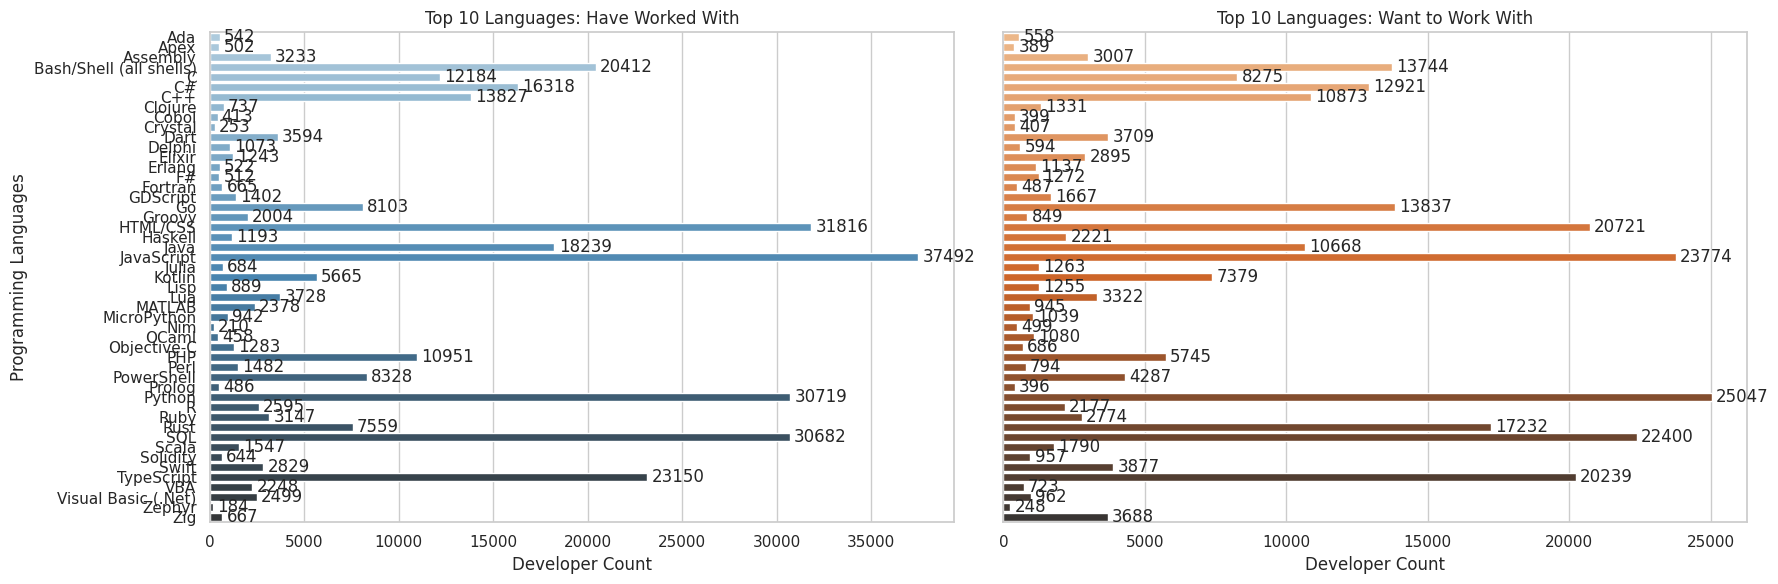

In [132]:
# Set style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
# 1. Plot 'Have Worked With' (Current usage)
sns.barplot(data= final_df, x='LanHaveWorkedWith', y=final_df.index, hue=final_df.index, ax=axes[0], palette="Blues_d")
axes[0].set_title('Top 10 Languages: Have Worked With')
axes[0].set_xlabel('Developer Count')
axes[0].set_ylabel('Programming Languages')
# 2. Plot 'Want to Work With' (Future desire)
sns.barplot(data= final_df, x='LanWantToWorkWith', y=final_df.index, hue=final_df.index, ax=axes[1], palette="Oranges_d")
axes[1].set_title('Top 10 Languages: Want to Work With')
axes[1].set_xlabel('Developer Count')
axes[1].set_ylabel('Programming Language')
# Add value labels automatically on top of/beside bars
for ax in axes:
    for container in ax.containers:
        ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

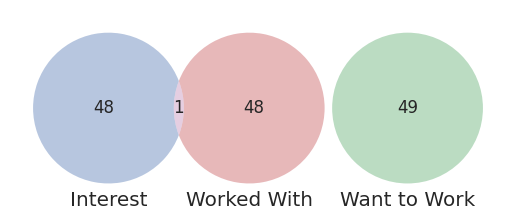

In [133]:
from matplotlib_venn import venn3

set1 = set(final_df['LanWantToWorkWith'])
set2 = set(final_df['LanHaveWorkedWith'])
set3 = set(final_df['LanInterestShift'])

# Plot a 3-circle Venn diagram
venn3([set1, set2, set3], 
      set_labels=('Worked With', 'Want to Work', 'Interest'))
plt.show()

### Step 7: Analyze Remote Work Trends


- Visualize the distribution of RemoteWork by region using a grouped bar chart or heatmap.


In [134]:
## Write your code here
df[['Country']].head()

,Country
0,United States of America
1,United Kingdom of Great Britain and Northern I...
2,United Kingdom of Great Britain and Northern I...
3,Canada
4,Norway


In [135]:
df['Country'].isnull().sum()

np.int64(6507)

In [136]:
mode_country = df['Country'].mode()[0]
print(mode_country)

United States of America


In [137]:
df['Country'] = df['Country'].fillna(mode_country)

In [138]:
df['Country'].isnull().sum()

np.int64(0)

In [139]:
import country_converter as coco
cc = coco.CountryConverter()
# Replace any unrecognized entries with the original value from the column
df['ISO3_Country'] = cc.pandas_convert(series=df['Country'], to='ISO3', not_found='Nomadic')
# If you specifically want to fill a column with its own values where mapping failed:

Nomadic not found in regex


In [140]:
df['ISO3_Country'].value_counts()

ISO3_Country
USA    17602
DEU     4947
IND     4231
GBR     3224
UKR     2672
       ...  
FSM        1
NRU        1
TCD        1
DJI        1
SLB        1
Name: count, Length: 183, dtype: int64

In [141]:
df_count = df.groupby('RemoteWork', as_index=False)['ISO3_Country'].value_counts()
df_count.head()

,RemoteWork,ISO3_Country,count
0,Hybrid,USA,8204
1,Hybrid,DEU,3098
2,Hybrid,IND,2290
3,Hybrid,GBR,1765
4,Hybrid,FRA,1344


In [142]:
# Filter for the specific country in the resulting DataFrame
specific_country = df_count[df_count['ISO3_Country'] == 'FRA']
specific_country

,RemoteWork,ISO3_Country,count
4,Hybrid,FRA,1344
177,In-person,FRA,357
342,Remote,FRA,409


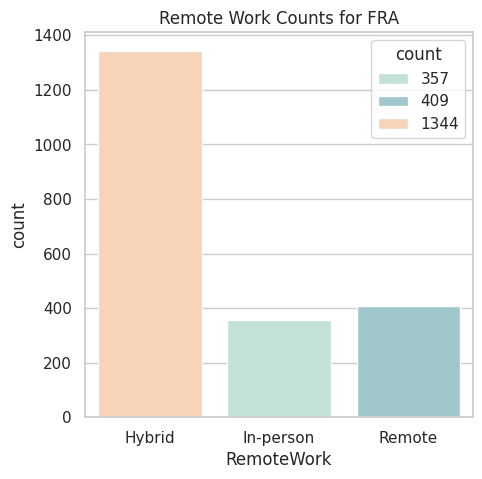

In [143]:
plt.figure(figsize=(5, 5)) 
# Plot using Seaborn barplot
sns.barplot(data=specific_country, x='RemoteWork', y='count', hue='count', palette='icefire')
plt.title("Remote Work Counts for FRA")
plt.show()

### Step 8: Correlation between Job Satisfaction and Experience


- Analyze the correlation between overall job satisfaction (`JobSat`) and `YearsCodePro`.
  
- Calculate the Pearson or Spearman correlation coefficient.


In [144]:
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')
df['JobSat'] = pd.to_numeric(df['JobSat'], errors='coerce')

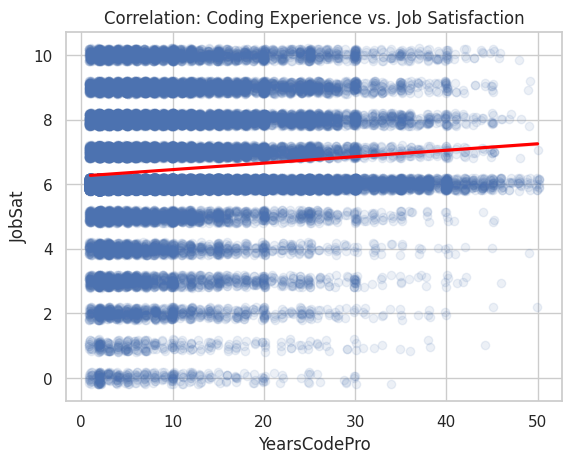

In [145]:
sns.regplot(data=df, x='YearsCodePro', y='JobSat', 
            x_jitter=0.2, y_jitter=0.2, 
            scatter_kws={'alpha':0.1}, line_kws={'color':'red'})
plt.title("Correlation: Coding Experience vs. Job Satisfaction")
plt.show()

In [146]:
# Calculate Spearman correlation

correlation = df['JobSat'].corr(df['YearsCodePro'], method='spearman')
print(f"Spearman Correlation: {correlation:.3f}")

Spearman Correlation: 0.185


### Step 9: Cross-tabulation Analysis (Employment vs. Education Level)


- Analyze the relationship between employment status (`Employment`) and education level (`EdLevel`).

- **Instruction**: Create a cross-tabulation using `pd.crosstab()` and visualize it with a stacked bar plot if possible.


In [147]:
## Write your code here
mapping = {
    'Primary/elementary school': 'Low',
    'Something else': 'Medium',
    'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)': 'Medium',
    'Some college/university study without earning a degree': 'Medium',
    'Associate degree (A.A., A.S., etc.)': 'Medium',
    'Bachelor’s degree (B.A., B.S., B.Eng., etc.)': 'High',
    'Master’s degree (M.A., M.S., M.Eng., MBA, etc.)': 'High',
    'Professional degree (JD, MD, Ph.D, Ed.D, etc.)': 'High'
}

# Apply Mapping
df['Education_Standardized'] = df['EdLevel'].map(mapping)
# For ordinals, convert to categorical
df['Education_Standardized'] = pd.Categorical(df['Education_Standardized'], categories=['Low', 'Medium', 'High'], ordered=True)

In [148]:
df['Education_Standardized'].value_counts()

Education_Standardized
High      43469
Medium    16169
Low        1146
Name: count, dtype: int64

In [149]:
df['Employment'] = df['Employment'].str.strip()

In [150]:
df['Employment'] = df['Employment'].str.lower()

In [151]:
df['Employment'].str.replace(r'[^a-zA-Z\s]', '', regex=True)

0        employed fulltime
1        employed fulltime
2        employed fulltime
3         student fulltime
4         student fulltime
               ...        
65432    employed fulltime
65433    employed fulltime
65434    employed fulltime
65435    employed fulltime
65436     student fulltime
Name: Employment, Length: 65437, dtype: object

In [152]:
df['Employment'].isnull().sum()

np.int64(0)

In [153]:
short_names = {
    'employed, full-time': 'FT',
    'employed, part-time': 'PT',
    'independent contractor, freelancer, or self-employed': 'Contract',
    'employed, full-time;independent contractor, freelancer, or self-employed' : 'FT Contract',
    'student, full-time;not employed, but looking for work;employed, part-time' : 'ST, FT-LW, PT',
    'student, full-time;not employed, but looking for work;not employed, and not looking for work' : 'ST, NE-LW, NE-NLW',
    'student, full-time;not employed, but looking for work;retired' : 'ST, FT-LW, R',
    'student, full-time;student, part-time;retired' : 'ST, FT, PT, R',
    'student, part-time;retired' : 'ST, PT, R',
    'not employed, but looking for work;independent contractor, freelancer, or self-employed;student, part-time;retired' : 'NE, LW, Contract, PT, R',
    'not employed, but looking for work;retired' : 'NE, LW, R',
    'student, full-time;independent contractor, freelancer, or self-employed;employed, part-time;retired': 'ST, FT, Contract, PT, R',
    'student, full-time;not employed, but looking for work;independent contractor, freelancer, or self-employed;student, part-time;employed, part-time;retired ' : 'ST, FT, PT, LW, Contract, R',
    'not employed, but looking for work': 'Searching',
    'employed, full-time;student, full-time;independent contractor, freelancer, or self-employed;student, part-time;retired' : 'E, FT, ST, Contractor, PT, R',
    'not employed, but looking for work;not employed, and not looking for work;student, part-time;employed, part-time' : 'NE, LW, NE, NLW, ST, PT, EM, PT',
    'not employed, but looking for work;independent contractor, freelancer, or self-employed;not employed, and not looking for work;retired' : 'NE, NLW, R',
    'student, full-time;not employed, but looking for work;independent contractor, freelancer, or self-employed;student, part-time;employed, part-time;retired' : 'ST, FT, NE, LW, Contractor, PT, E, PT',
    'student, full-time;not employed, but looking for work;independent contractor, freelancer, or self-employed;employed, part-time' : 'ST, FT, NE, LW, Contractor, PT',
    'student, full-time;not employed, but looking for work;student, part-time' : 'ST, FT; NE, LW; ST, PT',
    'student, full-time;student, part-time' : 'ST,FT;ST,PT',
    'student, full-time;student, part-time;employed, part-time' : 'ST,FT;ST,PT;E,PT',
    'student, part-time' : 'ST,PT',
    'student, part-time;employed, part-time' : 'ST,PT;E,PT',
    'student, full-time;independent contractor, freelancer, or self-employed;student, part-time;employed, part-time' : 'ST,FT;Contractor;ST,PT;E,PT',
    'student, full-time;not employed, and not looking for work' : 'ST,FT;NE,NLW',
    'student, full-time;not employed, but looking for work' : 'ST,FT;NE,LW',
    'student, full-time;not employed, but looking for work;independent contractor, freelancer, or self-employed' : 'ST,FT;NE,LW;Contractor',
    'student, full-time;not employed, but looking for work;independent contractor, freelancer, or self-employed;student, part-time' : 'ST,FT;NE,LW;Contractor;ST,PT',
    'employed, full-time;student, full-time;not employed, but looking for work;student, part-time;employed, part-time' : 'E,FT; ST,FT; NE,LW; ST,PT; E,PT',
    'employed, full-time;student, full-time;not employed, but looking for work;independent contractor, freelancer, or self-employed;employed, part-time' : 'E,FT;ST,FT;NE,LW;Contract;E,PT',
    'employed, full-time;independent contractor, freelancer, or self-employed;not employed, and not looking for work' : 'E,FT;Contractor;NE,NLW',
    'employed, full-time;independent contractor, freelancer, or self-employed;retired' : 'E,FT;Contractor;SE,R',
    'employed, full-time;not employed, but looking for work;not employed, and not looking for work;employed, part-time' : 'E,FT;NE,LW;NE,NLW;E,PT',
    'not employed, but looking for work;independent contractor, freelancer, or self-employed;not employed, and not looking for work;employed, part-time' : 'NE,LW;Contractor,E,PT',
    'student, full-time;retired' : 'ST, FT, R',
    'employed, full-time;not employed, but looking for work;student, part-time' : 'E, FT, NE, LW, PT',
    'not employed, and not looking for work;student, part-time;employed, part-time' : 'NE, LW; ST, PT; E,  PT'
}

In [154]:
df['Employment'] = df['Employment'].replace(short_names)

In [155]:
df['Employment'].value_counts()

Employment
FT                         39041
Contract                    4846
student, full-time          4709
FT Contract                 3557
Searching                   2341
                           ...  
NE,LW;Contractor,E,PT          1
ST, FT, R                      1
E, FT, NE, LW, PT              1
NE, LW; ST, PT; E,  PT         1
NE, LW, Contract, PT, R        1
Name: count, Length: 110, dtype: int64

In [156]:
ct = pd.crosstab(df['Employment'], df['Education_Standardized'], normalize='index')
print(ct)

Education_Standardized                                   Low    Medium  \
Employment                                                               
Contract                                            0.012572  0.287825   
E, FT, ST, Contractor, PT, R                        0.000000  0.000000   
E,FT; ST,FT; NE,LW; ST,PT; E,PT                     0.000000  0.000000   
E,FT;Contractor;NE,NLW                              0.500000  0.000000   
E,FT;Contractor;SE,R                                0.000000  1.000000   
...                                                      ...       ...   
student, full-time;not employed, and not lookin...  0.000000  1.000000   
student, full-time;not employed, and not lookin...  0.250000  0.625000   
student, full-time;not employed, but looking fo...  1.000000  0.000000   
student, full-time;not employed, but looking fo...  0.000000  0.000000   
student, full-time;not employed, but looking fo...  0.000000  0.000000   

Education_Standardized               

### Step 10: Export Cleaned Data


- Save the cleaned dataset to a new CSV file for further use or sharing.


In [157]:
## Write your code here
df.to_csv('cleaned_dataset.csv')

Have you computed the correlation between "Age" and other numerical columns such as "CompTotal" and "YearsCodePro?

In [158]:
df['Age'].isnull().sum()

np.int64(0)

In [159]:
df['Age'].value_counts()

Age
25-34 years old       23911
35-44 years old       14942
18-24 years old       14098
45-54 years old        6249
55-64 years old        2575
Under 18 years old     2568
65 years or older       772
Prefer not to say       322
Name: count, dtype: int64

In [160]:
df['CompTotal'].isnull().sum()

np.int64(31697)

In [161]:
mean_comp = df['CompTotal'].mean()
print(mean_comp)

2.9638411381149976e+145


In [162]:
df['CompTotal'] = df['CompTotal'].fillna(mean_comp)

In [163]:
df['CompTotal'].isnull().sum()

np.int64(0)

In [164]:
df['YearsCodePro'].isnull().sum()

np.int64(2906)

In [165]:
mean_yrcdpro = df['YearsCodePro'].mean()
print(mean_yrcdpro)

8.807119668644352


In [166]:
df['YearsCodePro'] = df['YearsCodePro'].fillna(mean_yrcdpro)

In [167]:
df['YearsCodePro'].isnull().sum()

np.int64(0)

In [168]:
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')
df['CompTotal'] = pd.to_numeric(df['CompTotal'], errors='coerce')

In [205]:
# Define the order manually
age_mapping = {
    'Under 18 years old': 1,
    '18-24 years old': 2,
    '25-34 years old': 3,
    '35-44 years old': 4,
    '45-54 years old': 5,
    '55-64 years old': 6,
    '65 years or older': 7
}

# Apply mapping to the DataFrame
df['Age_Numeric'] = df['Age'].map(age_mapping)

# Compute correlation
correlation_Age_CompTotal = df['Age_Numeric'].corr(df['CompTotal'])
correlation_Age_YearsCodePro = df['Age_Numeric'].corr(df['YearsCodePro'])

In [172]:
print(correlation_Age_CompTotal)

-0.001563081354995727


In [206]:
print(correlation_Age_YearsCodePro)

0.6813952558890242


Have you plotted a histogram for the "Age" column to understand its distribution?

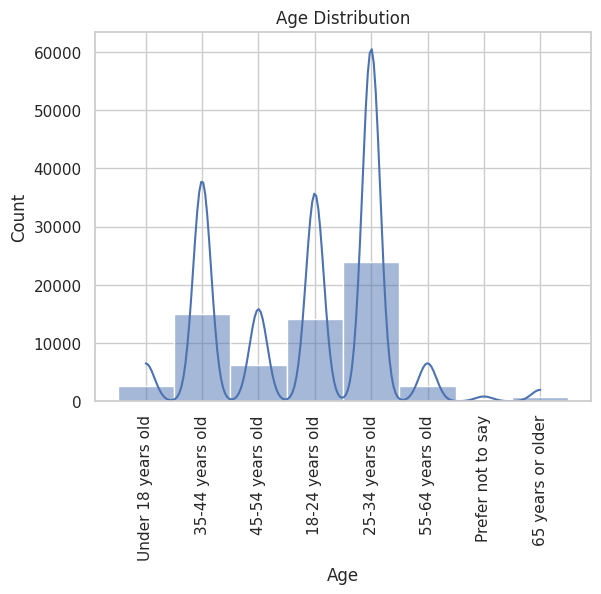

In [175]:
import seaborn as sns
import matplotlib.pyplot as plt
# Assuming df is your dataframe and 'Age' is the column
sns.histplot(df['Age'], kde=True)
plt.title('Age Distribution')
plt.xticks(rotation=90)
plt.show()

Have you calculated the interquartile range (IQR) to find the upper and lower bounds for outliers?

In [176]:
# 1. Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df['CompTotal'].quantile(0.25)
Q3 = df['CompTotal'].quantile(0.75)

# 2. Calculate the Interquartile Range (IQR)
IQR = Q3 - Q1

# 3. Define the outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 4. Identify outliers
outliers = df[(df['CompTotal'] < lower_bound) | (df['CompTotal'] > upper_bound)]

print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")
print(f"Number of Outliers: {len(outliers)}")

Lower Bound: -4.4457617071724965e+145
Upper Bound: 7.409602845287494e+145
Number of Outliers: 1


Have you created a box plot to detect outliers in the "CompTotal" column?

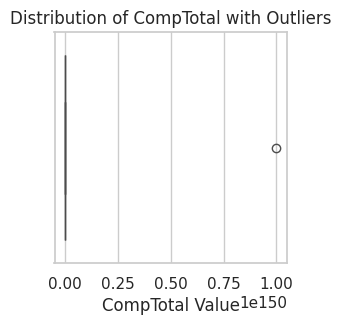

In [181]:
plt.figure(figsize=(3, 3))
# Create a horizontal boxplot for CompTotal
sns.boxplot(x=df['CompTotal'])

# Add labels and title
plt.title('Distribution of CompTotal with Outliers')
plt.xlabel('CompTotal Value')
plt.show()

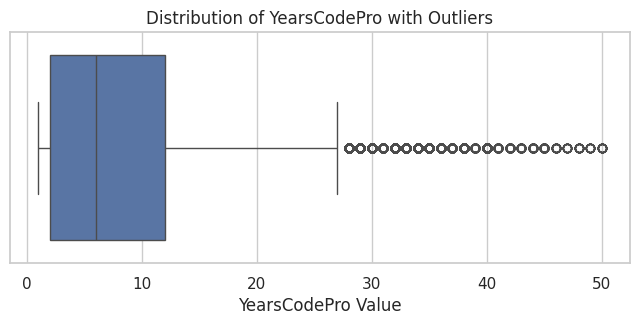

In [183]:
plt.figure(figsize=(8, 3))
# Create a horizontal boxplot for YearsCodePro
sns.boxplot(x=df['YearsCodePro'])

# Add labels and title
plt.title('Distribution of YearsCodePro with Outliers')
plt.xlabel('YearsCodePro Value')
plt.show()

Have you visualized the relationship between "Age" and "CompTotal" using a scatter plot?

In [193]:
df[['Age_Numeric','CompTotal']].head()

,Age_Numeric,CompTotal
0,1.0,2.963841e+145
1,4.0,2.963841e+145
2,5.0,2.963841e+145
3,2.0,2.963841e+145
4,2.0,2.963841e+145


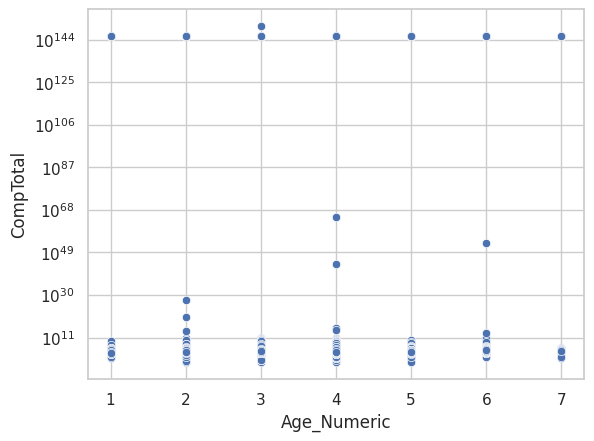

In [200]:
ax = sns.scatterplot(x='Age_Numeric', y='CompTotal', data=df)
ax.set_yscale('log')

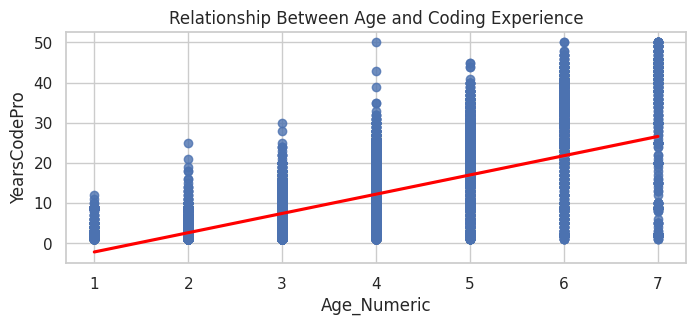

In [192]:
plt.figure(figsize=(8, 3))
# Basic Scatter Plot
#sns.scatterplot(x='Age_Numeric', y='YearsCodePro', data=df)

# Alternative: Regression Plot to see the trend line
sns.regplot(x='Age_Numeric', y='YearsCodePro', data=df, line_kws={"color":"red"})

plt.title('Relationship Between Age and Coding Experience')
plt.show()

Have you displayed the first few rows of the dataset using df.head()?

In [203]:
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat,ISO3_Country,Education_Standardized,Age_Numeric
0,1,I am a developer by profession,Under 18 years old,FT,Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,86155.287263,6.0,USA,Low,1.0
1,2,I am a developer by profession,35-44 years old,FT,Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,NaN,NaN,86155.287263,6.0,GBR,High,4.0
2,3,I am a developer by profession,45-54 years old,FT,Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,Appropriate in length,Easy,86155.287263,6.0,GBR,High,5.0
3,4,I am learning to code,18-24 years old,"student, full-time",Hybrid,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,Too long,Easy,86155.287263,6.0,CAN,Medium,2.0
4,5,I am a developer by profession,18-24 years old,"student, full-time",Hybrid,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,Too short,Easy,86155.287263,6.0,NOR,Medium,2.0


### Summary:


In this lab, you practiced key skills in exploratory data analysis, including:


- Examining the structure and content of the Stack Overflow survey dataset to understand its variables and data types.

- Identifying and addressing missing data to ensure the dataset's quality and completeness.

- Summarizing and visualizing key variables such as job satisfaction, programming languages, and remote work trends.

- Analyzing relationships in the data using techniques like:
    - Comparing programming languages respondents have worked with versus those they want to work with.
      
    - Exploring remote work preferences by region.

- Investigating correlations between professional coding experience and job satisfaction.

- Performing cross-tabulations to analyze relationships between employment status and education levels.


## Authors:
Ayushi Jain


### Other Contributors:
Rav Ahuja
Lakshmi Holla
Malika


Copyright © IBM Corporation. All rights reserved.
